In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [8]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(0)

In [9]:
df.drop_duplicates(inplace=True)

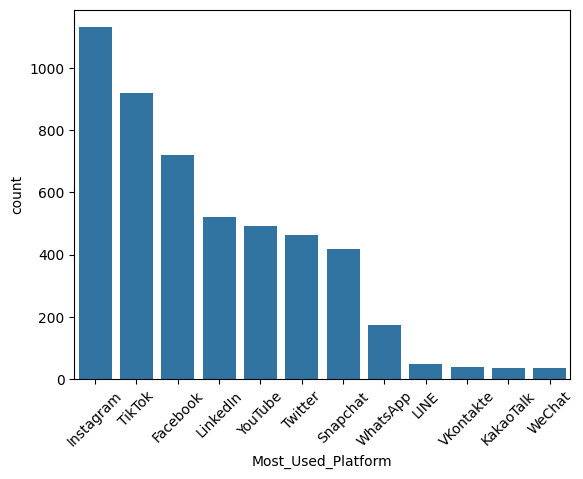

In [10]:
sns.countplot(x = df['Most_Used_Platform'], order = df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation = 45)
plt.show()

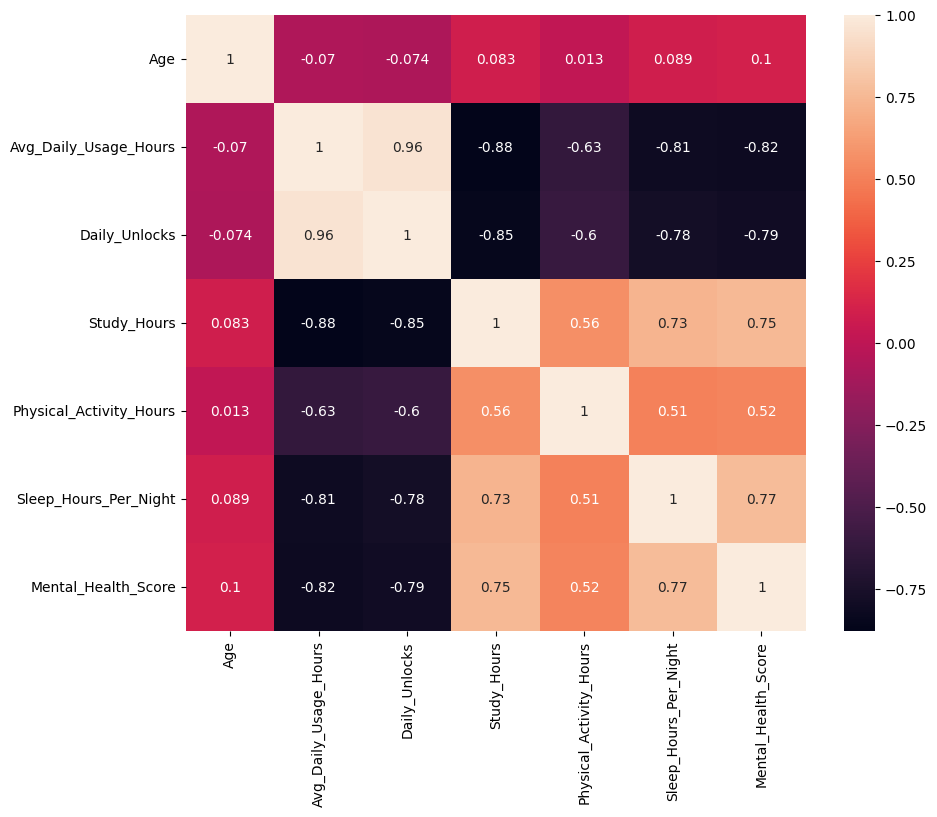

In [11]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(numeric_only = True), annot = True)
plt.show()

In [12]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

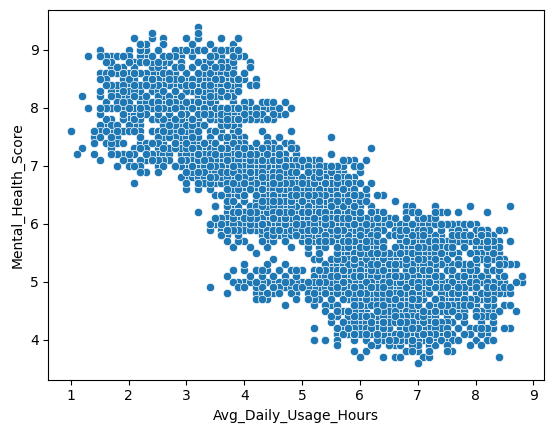

In [13]:
sns.scatterplot(x = df['Avg_Daily_Usage_Hours'], y = df['Mental_Health_Score'])
plt.show()

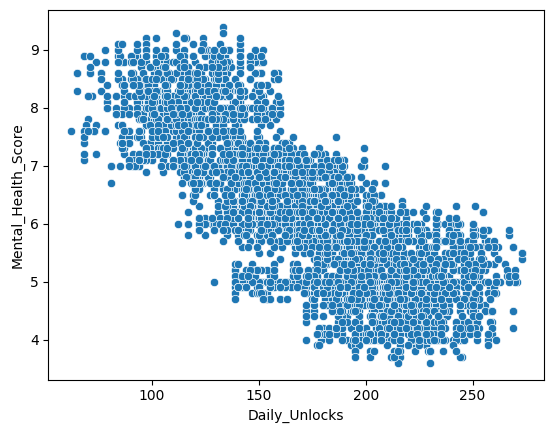

In [14]:
sns.scatterplot(x = df['Daily_Unlocks'], y = df['Mental_Health_Score'])
plt.show()

In [15]:
df['Stress_Level'].value_counts()

,count
Stress_Level,
Very High,1621
High,1439
Medium,1295
Low,643


<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

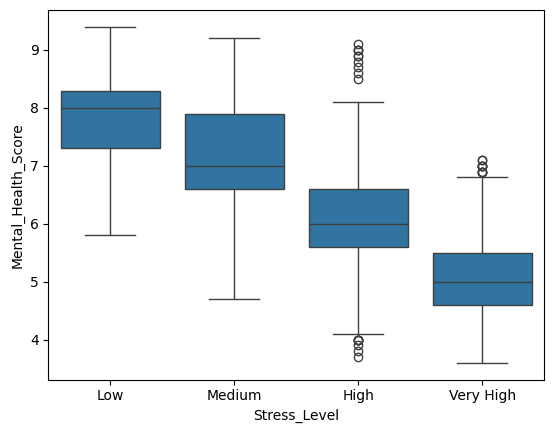

In [16]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x = df['Stress_Level'], y = df['Mental_Health_Score'], order=order)

In [17]:
df['Country'].value_counts()

,count
Country,
Other,1879
India,389
USA,354
Canada,230
Australia,198
...,...
Armenia,1
Bosnia,1
Kuwait,1


In [18]:
top_ten_country = df["Country"].value_counts().index[:10].tolist()
def top_country(Country):
  if Country in top_ten_country:
    return Country
  else:
    return 'Other'

In [19]:
df['Country'] = df['Country'].apply(top_country)

In [20]:
numeric_col = df.select_dtypes(include = "number")
Q1 = numeric_col.quantile(0.25)
Q3 = numeric_col.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = (numeric_col < lower_fence) | (numeric_col > upper_fence)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    12
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [21]:

num_cols = df.select_dtypes(include='number')
num_cols.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [22]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [23]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [24]:
from sklearn.model_selection import train_test_split
Skewed_col = ['Study_Hours']
Numeric_features = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours", "Sleep_Hours_Per_Night"]
ordinal_features = ['Stress_Level']
one_hot_encoding_features = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Country"]
features = Skewed_col + Numeric_features + ordinal_features + one_hot_encoding_features
X = df[features]
y = df['Mental_Health_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

skew_pipline = Pipeline(steps=[
    ("log_tranform", FunctionTransformer(np.log1p)),
    ("scaler", StandardScaler())
])

num_features_pipeline = Pipeline(steps = [
    ("scaler", StandardScaler())

])

ordinal_features_pipeline = Pipeline(steps = [
    ("ordinal_encoder", OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

one_hot_encoding_features_pipeline = Pipeline(steps = [
    ("one_hot_encoder", OneHotEncoder(handle_unknown = "ignore"))
])

preprocessor = ColumnTransformer(transformers = [
    ("skew_pipline", skew_pipline, Skewed_col),
    ("num_features_pipeline", num_features_pipeline, Numeric_features),
    ("ordinal_features_pipeline", ordinal_features_pipeline, ordinal_features),
    ("one_hot_encoding_features_pipeline",one_hot_encoding_features_pipeline, one_hot_encoding_features)
])

In [33]:
from matplotlib import rc
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_test_pred = lr_pipeline.predict(X_test)
lr_train_pred = lr_pipeline.predict(X_train)

lr_r2_test = r2_score(y_test, lr_test_pred)
lr_r2_train = r2_score(y_train, lr_train_pred)
lr_mse_test = mean_absolute_error(y_test, lr_test_pred)

print(f"Accuracy of traning Data: {lr_r2_train}")
print(f"Accuracy of testing Data: {lr_r2_test}")
print(f"Mean absolute Error mse: {lr_mse_test}")




Accuracy of traning Data: 0.7255085942476625
Accuracy of testing Data: 0.739160612205956
Mean absolute Error mse: 0.5349030510853536


In [34]:
from sklearn.ensemble import RandomForestRegressor
rf_pipline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

rf_pipline.fit(X_train, y_train)
rf_train_pred = rf_pipline.predict(X_train)
rf_test_pred = rf_pipline.predict(X_test)


rf_r2_train = r2_score(y_train, rf_train_pred)
rf_r2_test = r2_score(y_test, rf_test_pred)

rf_mse_test = mean_absolute_error(y_test, rf_test_pred)

print(f"Accuracy of traning Data: {rf_r2_train}")
print(f"Accuracy of testing Data: {rf_r2_test}")
print(f"Mean absolute Error mse: {rf_mse_test}")

Accuracy of traning Data: 0.9818176564322069
Accuracy of testing Data: 0.8848441632669826
Mean absolute Error mse: 0.3347018800000002


In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}
random_seach_cv = RandomizedSearchCV(
    estimator=rf_pipline,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring = 'r2',
    random_state=42,
    n_jobs=-1,
)
random_seach_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew_pipline',
                                                                               Pipeline(steps=[('log_tranform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('num_features_pipeline',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlock...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Country'])])),
                                             ('model',
                                              RandomForestRegressor())]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2')

In [45]:
random_seach_cv.best_params_

{'model__n_estimators': 300,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_depth': 30}

In [48]:
Random_pipline = random_seach_cv.best_estimator_
Random_y_pred = Random_pipline.predict(X_test)
print(f"Accuracy of r2_score: {r2_score(y_test, Random_y_pred)}")
print(f"Accuacy of mse: {mean_absolute_error(y_test, Random_y_pred)}")

Accuracy of r2_score: 0.8846259282757427
Accuacy of mse: 0.33797570379238523


In [49]:

import joblib
joblib.dump(rf_pipline, 'mental_health_model.pkl')

['mental_health_model.pkl']